# Parallel MNIST: Dense vs Block-Sparse Baselines

Comparing a dense MLP against a block-sparse MLP (oracle structure) on the parallel MNIST task.
- **Stationary:** Does the right sparse structure yield better capacity efficiency?
- **Non-stationary:** Does the right sparse structure yield faster adaptation?

In [1]:
from collections import defaultdict
import itertools
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
# from phd.research_utils.scripts.mlflow_download import download_experiment
# download_experiment(
#     experiment='parallel-mnist',
#     output_dir='data',
# )

In [3]:
config_dfs, run_dfs = load_experiment_data(
    'data/parallel_mnist_params.csv',
    'data/parallel_mnist_metrics.csv',
)

# Drop summary-only rows: these are end-of-run rows where loss is NaN but
# summary metrics (asymptotic_loss, num_params) are populated. They are
# logging artifacts, not training data, and would poison cumulative/mean metrics.
for k in run_dfs:
    rdf = run_dfs[k]
    summary_mask = rdf['loss'].isna() & rdf['asymptotic_loss'].notna()
    run_dfs[k] = rdf[~summary_mask].copy()

{k: len(v) for k, v in config_dfs.items()}

{'parallel_mnist_block_sparse_nonstationary_v2': 15,
 'parallel_mnist_dense_nonstationary_v2': 15,
 'parallel_mnist_block_sparse_stationary_v2': 30,
 'parallel_mnist_dense_stationary_v2': 30,
 'parallel_mnist_block_sparse_stationary': 30,
 'parallel_mnist_dense_stationary': 30}

---
## 1. Stationary Experiment

Using the v2 sweeps (5 sub-tasks, centered LR ranges).

In [4]:
DENSE_STAT = 'parallel_mnist_dense_stationary_v2'
SPARSE_STAT = 'parallel_mnist_block_sparse_stationary_v2'

# Find the best LR separately for each (model_type, target_params) combination.
# split_dfs_by_split_vars=True gives separate keys per target_params value.
stat_sweeps = {k: v for k, v in config_dfs.items() if k in [DENSE_STAT, SPARSE_STAT]}
stat_runs = {k: v for k, v in run_dfs.items() if k in [DENSE_STAT, SPARSE_STAT]}

best_stat_configs, best_stat_runs, best_stat_vals = get_best_ablation_values(
    stat_sweeps, stat_runs,
    sweep_ablation_vars={DENSE_STAT: ['optimizer.learning_rate'], SPARSE_STAT: ['optimizer.learning_rate']},
    sweep_split_vars={DENSE_STAT: ['model.target_params'], SPARSE_STAT: ['model.target_params']},
    metric_col='loss',
    metric_direction='min',
    metric_type='final_avg',
    split_dfs_by_split_vars=True,
)


=== parallel_mnist_block_sparse_stationary_v2 ===

Configuration: model.target_params=2**15 | # runs: 1
  Best optimizer.learning_rate=2**-11

Configuration: model.target_params=2**16 | # runs: 1
  Best optimizer.learning_rate=2**-11

Configuration: model.target_params=2**17 | # runs: 1
  Best optimizer.learning_rate=2**-11

Configuration: model.target_params=2**18 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: model.target_params=2**19 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: model.target_params=2**20 | # runs: 1
  Best optimizer.learning_rate=2**-13


=== parallel_mnist_dense_stationary_v2 ===

Configuration: model.target_params=2**15 | # runs: 1
  Best optimizer.learning_rate=2**-13

Configuration: model.target_params=2**16 | # runs: 1
  Best optimizer.learning_rate=2**-13

Configuration: model.target_params=2**17 | # runs: 1
  Best optimizer.learning_rate=2**-13

Configuration: model.target_params=2**18 | # runs: 1
  Best optimizer.learn

In [5]:
# Combine dense and sparse best runs into unified DataFrames with a 'Model' column.
# Each key looks like 'parallel_mnist_dense_stationary_v2&model.target_params=2**15'

combined_stat_runs = []
combined_stat_configs = []

for key, cdf in best_stat_configs.items():
    rdf = best_stat_runs[key]
    if DENSE_STAT in key:
        model_label = 'Dense MLP'
    elif SPARSE_STAT in key:
        model_label = 'Block-Sparse MLP'
    else:
        continue
    cdf = cdf.copy()
    cdf['Model'] = model_label
    combined_stat_configs.append(cdf)
    combined_stat_runs.append(rdf)

all_stat_config = pd.concat(combined_stat_configs, ignore_index=True)
all_stat_run = pd.concat(combined_stat_runs, ignore_index=True)
valid_ids = set(all_stat_config['run_id'].unique())
all_stat_run = all_stat_run[all_stat_run['run_id'].isin(valid_ids)].copy()

print(f'Combined: {len(all_stat_config)} configs, {len(all_stat_run)} run rows')
print(f'Models: {all_stat_config["Model"].value_counts().to_dict()}')

Combined: 12 configs, 1200 run rows
Models: {'Block-Sparse MLP': 6, 'Dense MLP': 6}


### Learning Curves by Model Size

If the block-sparse model has the right structure for this task, it should learn faster
than the dense model at the same parameter budget — reaching lower loss in fewer steps.
Each curve uses the best learning rate for that specific model type and size.

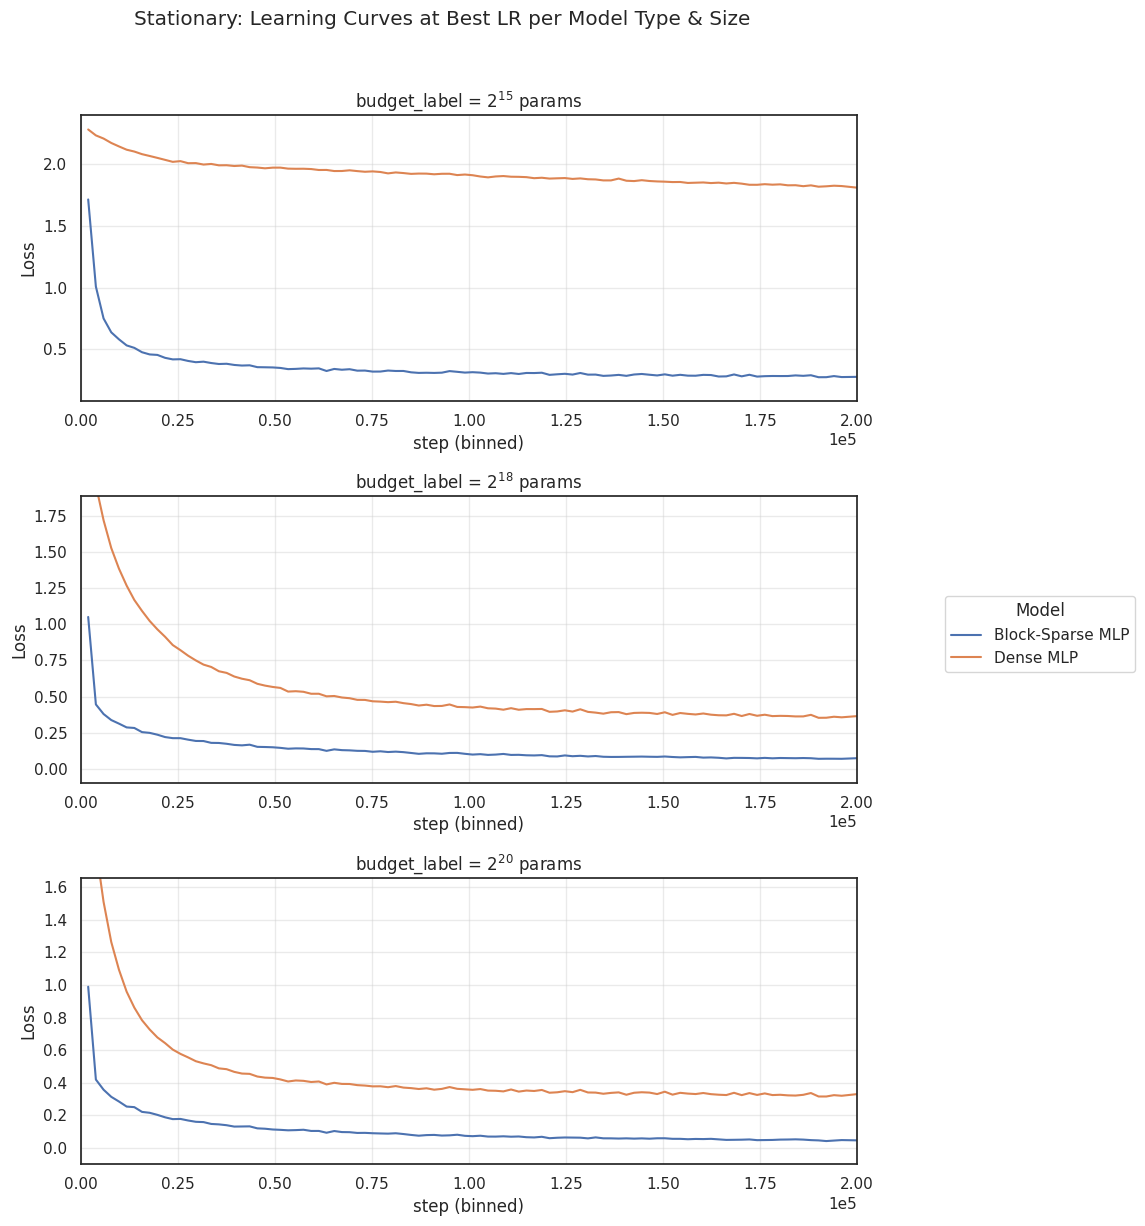

In [29]:
# Pick smallest, mid, largest target_params
all_budgets = sorted(all_stat_config['model.target_params'].dropna().unique())
budgets_to_plot = [all_budgets[0], all_budgets[len(all_budgets)//2], all_budgets[-1]]

# Add readable budget labels for subplot titles
all_stat_config['budget_label'] = all_stat_config['model.target_params'].apply(
    lambda x: f'$2^{{{int(round(math.log2(x)))}}}$ params' if pd.notna(x) else ''
)

# Filter to selected budgets — must filter both config and run to keep them in sync
lc_config = all_stat_config[all_stat_config['model.target_params'].isin(budgets_to_plot)].copy()
lc_run = all_stat_run[all_stat_run['run_id'].isin(lc_config['run_id'])].copy()

plot_learning_curves(
    run_df=lc_run,
    config_df=lc_config,
    subplot_col='budget_label',
    subplot_values=[f'$2^{{{int(round(math.log2(b)))}}}$ params' for b in budgets_to_plot],
    n_bins=100,
    figsize=(9, 12),
    max_cols=1,
    same_y_axis=False,
    y_col='loss',
    y_label='Loss',
    hue_col='Model',
    legend_title='Model',
    show_ci=True,
)
plt.suptitle('Stationary: Learning Curves at Best LR per Model Type & Size', y=1.02)
plt.tight_layout()
plt.show()

### Asymptotic Performance vs Parameter Budget

The block-sparse model should achieve better asymptotic performance than the dense model,
especially at smaller parameter budgets where the dense network wastes capacity on
irrelevant cross-task connections. At large budgets, both should converge.

**How other variables are handled:** For each point on the x-axis (a specific parameter
budget), the learning rate is chosen independently as whichever value minimized loss for
that (model type, parameter budget) pair. Different points may use different learning rates.

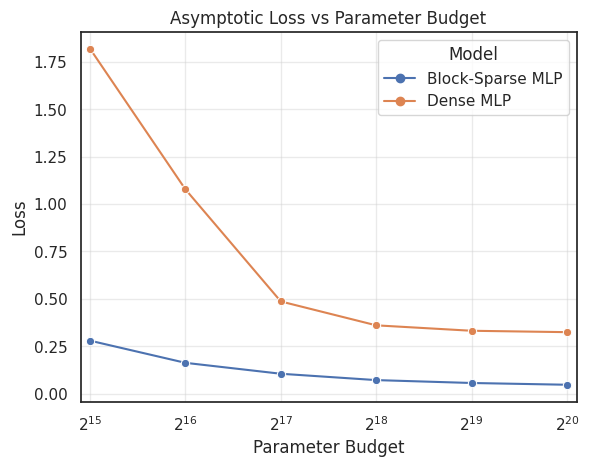

In [7]:
plot_param_sensitivity(
    run_df=all_stat_run,
    config_df=all_stat_config,
    x_col='model.target_params',
    title='Asymptotic Loss vs Parameter Budget',
    x_label='Parameter Budget',
    y_label='Loss',
    metric_col='loss',
    metric_type='final_avg',
    hue_col='Model',
    legend_title='Model',
    show_ci=True,
    pow_2_x_axis=True,
)
plt.show()

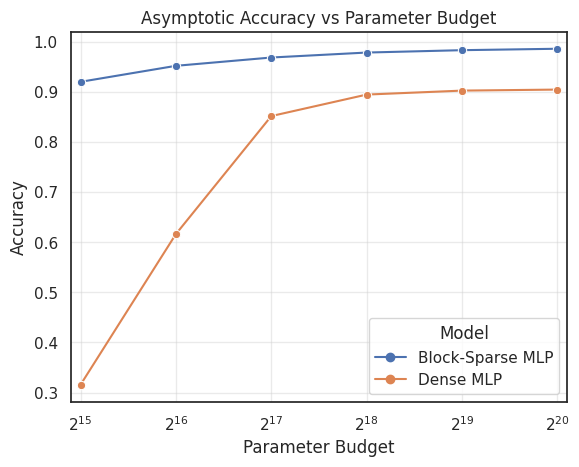

In [8]:
plot_param_sensitivity(
    run_df=all_stat_run,
    config_df=all_stat_config,
    x_col='model.target_params',
    title='Asymptotic Accuracy vs Parameter Budget',
    x_label='Parameter Budget',
    y_label='Accuracy',
    metric_col='accuracy',
    metric_type='final_avg',
    hue_col='Model',
    legend_title='Model',
    show_ci=True,
    pow_2_x_axis=True,
)
plt.show()

---
## 2. Non-Stationary Experiment

Using the v2 sweeps (5 sub-tasks, target_params=2^19).

In [9]:
DENSE_NS = 'parallel_mnist_dense_nonstationary_v2'
SPARSE_NS = 'parallel_mnist_block_sparse_nonstationary_v2'

# Find the best LR separately for each (model_type, permute_period) combination.
ns_sweeps = {k: v for k, v in config_dfs.items() if k in [DENSE_NS, SPARSE_NS]}
ns_runs = {k: v for k, v in run_dfs.items() if k in [DENSE_NS, SPARSE_NS]}

best_ns_configs, best_ns_runs, best_ns_vals = get_best_ablation_values(
    ns_sweeps, ns_runs,
    sweep_ablation_vars={DENSE_NS: ['optimizer.learning_rate'], SPARSE_NS: ['optimizer.learning_rate']},
    sweep_split_vars={DENSE_NS: ['dataset.permute_period'], SPARSE_NS: ['dataset.permute_period']},
    metric_col='loss',
    metric_direction='min',
    metric_type='cumulative',
    split_dfs_by_split_vars=True,
)


=== parallel_mnist_block_sparse_nonstationary_v2 ===

Configuration: dataset.permute_period=2000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permute_period=5000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permute_period=10000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permute_period=25000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permute_period=50000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12


=== parallel_mnist_dense_nonstationary_v2 ===

Configuration: dataset.permute_period=2000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permute_period=5000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permute_period=10000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permute_period=25000.0 | # runs: 1
  Best optimizer.learning_rate=2**-12

Configuration: dataset.permu

In [10]:
# Combine dense and sparse best runs
combined_ns_runs = []
combined_ns_configs = []

for key, cdf in best_ns_configs.items():
    rdf = best_ns_runs[key]
    if DENSE_NS in key:
        model_label = 'Dense MLP'
    elif SPARSE_NS in key:
        model_label = 'Block-Sparse MLP'
    else:
        continue
    cdf = cdf.copy()
    cdf['Model'] = model_label
    combined_ns_configs.append(cdf)
    combined_ns_runs.append(rdf)

all_ns_config = pd.concat(combined_ns_configs, ignore_index=True)
all_ns_run = pd.concat(combined_ns_runs, ignore_index=True)
valid_ids = set(all_ns_config['run_id'].unique())
all_ns_run = all_ns_run[all_ns_run['run_id'].isin(valid_ids)].copy()

print(f'Combined: {len(all_ns_config)} configs, {len(all_ns_run)} run rows')

Combined: 10 configs, 2500 run rows


In [11]:
# Compute stationary asymptotic loss baselines for horizontal reference lines.
# Use the v2 stationary sweeps at target_params=2^19 (same budget as non-stationary).
TARGET_PARAMS_NS = 524288.0  # 2^19

stationary_baselines = {}  # model_label -> asymptotic loss
for sweep_name, model_label in [(DENSE_STAT, 'Dense MLP'), (SPARSE_STAT, 'Block-Sparse MLP')]:
    for key, cdf in best_stat_configs.items():
        if sweep_name in key and TARGET_PARAMS_NS in cdf['model.target_params'].values:
            rdf = best_stat_runs[key]
            max_step = rdf['step'].max()
            tail = rdf[rdf['step'] >= max_step * 0.95]
            stationary_baselines[model_label] = tail['loss'].mean()
            break

print('Stationary baselines at 2^19 params:', {k: f'{v:.4f}' for k, v in stationary_baselines.items()})

Stationary baselines at 2^19 params: {'Dense MLP': '0.3318', 'Block-Sparse MLP': '0.0564'}


### Learning Curves by Permutation Period

The block-sparse model should adapt faster to label permutations because only the affected
block's weights need to re-learn, while the dense model must adjust all weights. After each
permutation event the loss spikes; the block-sparse model should recover more quickly,
closing in on its stationary performance faster. Dotted horizontal lines show the
stationary asymptotic loss for reference.

Each curve uses the best learning rate for that model type and permutation period.

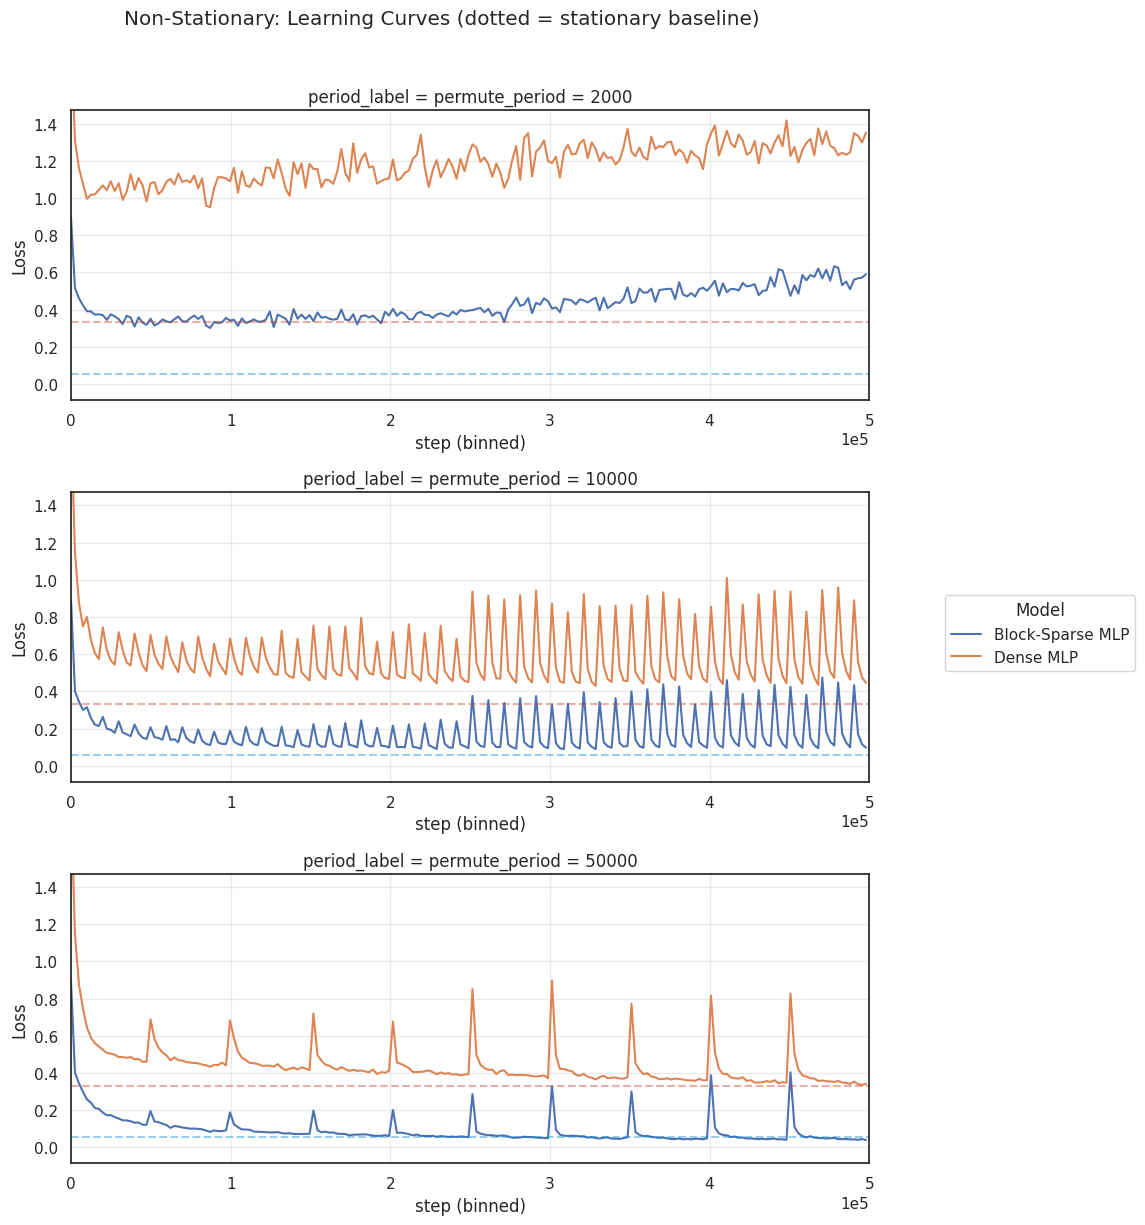

In [30]:
all_periods = sorted(all_ns_config['dataset.permute_period'].dropna().unique())
periods_to_plot = [all_periods[0], all_periods[len(all_periods)//2], all_periods[-1]]

all_ns_config['period_label'] = all_ns_config['dataset.permute_period'].apply(
    lambda x: f'permute_period = {int(x)}' if pd.notna(x) else ''
)

lc_ns_config = all_ns_config[all_ns_config['dataset.permute_period'].isin(periods_to_plot)].copy()
lc_ns_run = all_ns_run[all_ns_run['run_id'].isin(lc_ns_config['run_id'])].copy()

plot_learning_curves(
    run_df=lc_ns_run,
    config_df=lc_ns_config,
    subplot_col='period_label',
    subplot_values=[f'permute_period = {int(p)}' for p in periods_to_plot],
    n_bins=200,
    figsize=(9, 12),
    max_cols=1,
    same_y_axis=True,
    y_col='loss',
    y_label='Loss',
    hue_col='Model',
    legend_title='Model',
    show_ci=True,
)

# Add stationary baselines as dotted horizontal lines
colors = get_color_palette(['Dense MLP', 'Block-Sparse MLP'])
for ax in plt.gcf().axes:
    for model_label, baseline in stationary_baselines.items():
        ax.axhline(baseline, color=colors[model_label], linestyle='--', alpha=0.4, linewidth=1.5)

plt.suptitle('Non-Stationary: Learning Curves (dotted = stationary baseline)', y=1.02)
plt.tight_layout()
plt.show()

### Average Performance vs Permutation Period

The block-sparse model should maintain lower average loss across all permutation frequencies.
The gap should be largest at short permutation periods (fast changes) where the dense
network cannot adapt quickly enough. Unlike the stationary case where increasing parameters
can close the gap, here model size is fixed — the advantage comes purely from structural
credit assignment.

**How other variables are handled:** For each point on the x-axis (a specific permutation
period), the learning rate is chosen independently as whichever value minimized cumulative
loss for that (model type, permutation period) pair. Different points may use different
learning rates.

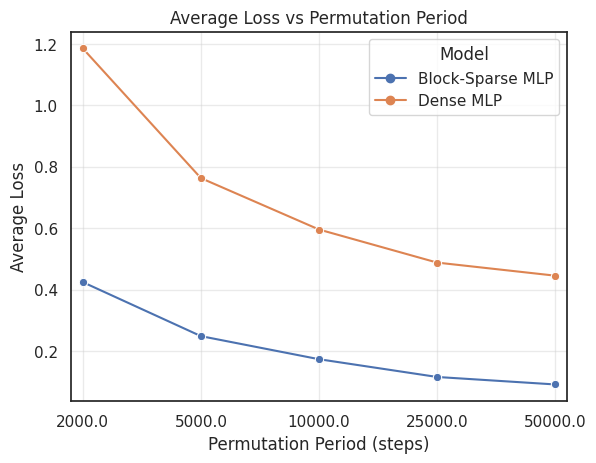

In [13]:
# Compute per-run average loss and accuracy, then merge with config for plotting
ns_avg = all_ns_run.groupby('run_id').agg(
    avg_loss=('loss', 'mean'),
    avg_accuracy=('accuracy', 'mean'),
).reset_index()
ns_plot_df = ns_avg.merge(all_ns_config, on='run_id')

plot_param_sensitivity(
    run_df=ns_plot_df,
    config_df=None,
    x_col='dataset.permute_period',
    title='Average Loss vs Permutation Period',
    x_label='Permutation Period (steps)',
    y_label='Average Loss',
    metric_col='avg_loss',
    metric_type='last',
    hue_col='Model',
    legend_title='Model',
    show_ci=True,
)
plt.show()

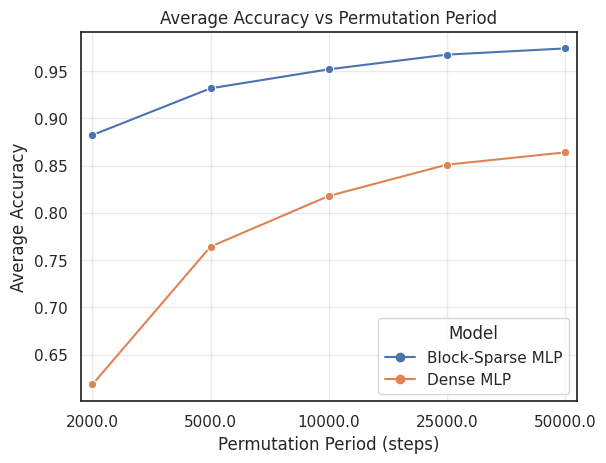

In [14]:
plot_param_sensitivity(
    run_df=ns_plot_df,
    config_df=None,
    x_col='dataset.permute_period',
    title='Average Accuracy vs Permutation Period',
    x_label='Permutation Period (steps)',
    y_label='Average Accuracy',
    metric_col='avg_accuracy',
    metric_type='last',
    hue_col='Model',
    legend_title='Model',
    show_ci=True,
)
plt.show()